18/05/2023
Han
# MHW Heat Budget
Data
- ERA5 : flux
- BRAN : mld,pott,u,v



In [9]:
# Module 引入
import os
import datetime
import numpy as np
import scipy as sp
import pandas as pd
import netCDF4 as nc
import PIL.Image as Image
import cartopy.crs as ccrs
import marineHeatWaves as mhw
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
from datetime import date
from tqdm import notebook
from os import listdir
from os.path import join, isfile
from scipy.stats import pearsonr
from scipy.interpolate import RegularGridInterpolator
from scipy.signal import detrend
from matplotlib.backends.backend_agg import FigureCanvasAgg
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, Executor


In [10]:
data = np.load('ERAdata.npz')
# LH = data['LH']
# SH = data['SH']
# LW = data['LW']
# SW = data['SW']
lon = data['lon']
lat = data['lat']
times=pd.date_range('1993-01-01','2022-12-31',freq='1D')

In [11]:
# 常用函数

## 从NC文件时间转PD时间
def cftime2pdtime(cf):
    return pd.to_datetime(datetime.datetime(cf.year,cf.month,cf.day,cf.hour))

## 获取文件夹里所有NC文件
def getfiles(filed):
    files=listdir(filed)
    files.sort()
    files=files[0:]
    files_n=[filed+'/'+i for i in files]
    return files_n

def runavg(ts, w):
    '''
    Performs a running average of an input time series using uniform window
    of width w. This function assumes that the input time series is periodic.
    Inputs:
      ts            Time series [1D numpy array]
      w             Integer length (must be odd) of running average window
    Outputs:
      ts_smooth     Smoothed time series
    Written by Eric Oliver, Institue for Marine and Antarctic Studies, University of Tasmania, Feb-Mar 2015
    '''
    # Original length of ts
    N = len(ts)
    # make ts three-fold periodic
    ts = np.append(ts, np.append(ts, ts))
    # smooth by convolution with a window of equal weights
    ts_smooth = np.convolve(ts, np.ones(w)/w, mode='same')
    # Only output central section, of length equal to the original length of ts
    ts = ts_smooth[N:2*N]

    return ts

def Clim(t, data, climatologyPeriod=[None,None],  windowHalfWidth=5, smoothPercentile=True, smoothPercentileWidth=31,alternateClimatology=False, Ly=False):
    T = len(t)
    year = np.zeros((T))
    month = np.zeros((T))
    day = np.zeros((T))
    doy = np.zeros((T))
    for i in range(T):
        year[i] = date.fromordinal(t[i]).year
        month[i] = date.fromordinal(t[i]).month
        day[i] = date.fromordinal(t[i]).day
    # Leap-year baseline for defining day-of-year values
    year_leapYear = 2012 # This year was a leap-year and therefore doy in range of 1 to 366
    t_leapYear = np.arange(date(year_leapYear, 1, 1).toordinal(),date(year_leapYear, 12, 31).toordinal()+1)
    dates_leapYear = [date.fromordinal(tt.astype(int)) for tt in t_leapYear]
    month_leapYear = np.zeros((len(t_leapYear)))
    day_leapYear = np.zeros((len(t_leapYear)))
    doy_leapYear = np.zeros((len(t_leapYear)))
    for tt in range(len(t_leapYear)):
        month_leapYear[tt] = date.fromordinal(t_leapYear[tt]).month
        day_leapYear[tt] = date.fromordinal(t_leapYear[tt]).day
        doy_leapYear[tt] = t_leapYear[tt] - date(date.fromordinal(t_leapYear[tt]).year,1,1).toordinal() + 1
    # Calculate day-of-year values
    for tt in range(T):
        doy[tt] = doy_leapYear[(month_leapYear == month[tt]) * (day_leapYear == day[tt])]

    # Constants (doy values for Feb-28 and Feb-29) for handling leap-years
    feb28 = 59
    feb29 = 60

    # Set climatology period, if unset use full range of available data
    if (climatologyPeriod[0] is None) or (climatologyPeriod[1] is None):
        climatologyPeriod[0] = year[0]
        climatologyPeriod[1] = year[-1]

    #
    # Calculate threshold and seasonal climatology (varying with day-of-year)
    #

    # if alternate temperature time series is supplied for the calculation of the climatology
    if alternateClimatology:
        tClim = alternateClimatology[0] # type: ignore
        tempClim = alternateClimatology[1] # type: ignore
        TClim = len(tClim)
        yearClim = np.zeros((TClim))
        monthClim = np.zeros((TClim))
        dayClim = np.zeros((TClim))
        doyClim = np.zeros((TClim))
        for i in range(TClim):
            yearClim[i] = date.fromordinal(tClim[i]).year
            monthClim[i] = date.fromordinal(tClim[i]).month
            dayClim[i] = date.fromordinal(tClim[i]).day
            doyClim[i] = doy_leapYear[(month_leapYear == monthClim[i]) * (day_leapYear == dayClim[i])]
    else:
        tempClim = data.copy()
        TClim = np.array([T]).copy()[0]
        yearClim = year.copy()
        monthClim = month.copy()
        dayClim = day.copy()
        doyClim = doy.copy()
    
    
    
    lenClimYear = 366
    # Start and end indices
    clim_start = np.where(yearClim == climatologyPeriod[0])[0][0]
    clim_end = np.where(yearClim == climatologyPeriod[1])[0][-1]
    # Inialize arrays
    seas_climYear = np.NaN*np.zeros(lenClimYear)
    clim = {}
    clim['seas'] = np.NaN*np.zeros(TClim)
    # Loop over all day-of-year values, and calculate threshold and seasonal climatology across years
    for d in range(1,lenClimYear+1):
        # Special case for Feb 29
        if d == feb29:
            continue
        # find all indices for each day of the year +/- windowHalfWidth and from them calculate the threshold
        tt0 = np.where(doyClim[clim_start:clim_end+1] == d)[0] 
        # If this doy value does not exist (i.e. in 360-day calendars) then skip it
        if len(tt0) == 0:
            continue
        tt = np.array([])
        for w in range(-windowHalfWidth, windowHalfWidth+1):
            tt = np.append(tt, clim_start+tt0 + w)
        tt = tt[tt>=0] # Reject indices "before" the first element
        tt = tt[tt<TClim] # Reject indices "after" the last element
        seas_climYear[d-1] = np.nanmean(tempClim[tt.astype(int)])
    # Special case for Feb 29
    seas_climYear[feb29-1] = 0.5*seas_climYear[feb29-2] + 0.5*seas_climYear[feb29]

    #return seas_climYear
    # Smooth if desired
    if smoothPercentile:
        # If the length of year is < 365/366 (e.g. a 360 day year from a Climate Model)
        if Ly:

            valid = ~np.isnan(seas_climYear)
            seas_climYear[valid] = runavg(seas_climYear[valid], smoothPercentileWidth)
        # >= 365-day year
        else:

            seas_climYear = runavg(seas_climYear, smoothPercentileWidth)

    #print(doy)
    #clim['seas'] = seas_climYear[doy.astype(int)-1]

    # Save vector indicating which points in temp are missing values
    #clim['missing'] = np.isnan(data)
    # Set all remaining missing temp values equal to the climatology
    #data[np.isnan(data)] = clim['seas'][np.isnan(data)]

    return seas_climYear[doy.astype(int)-1]

In [12]:
# 常量

YEARL=1993#Clim 基线期起点
YEARR=2022#Clim 基线期终点
t= np.arange(date(1993,1,1).toordinal(),date(2022,12,31).toordinal()+1)# For ClimCal
ts=pd.date_range('1993-01-01','2022-12-31',freq='1d')

# LATU=50+0.8
# LATD=40-0.8
# LONL=225+2
# LONR=200-2

## 数据准备

In [13]:
Bran_temp=np.load('/lustre/home/yuhanxue/bran_temp.npy')
Bran_u=np.load('/lustre/home/yuhanxue/bran_u.npy')
Bran_v=np.load('/lustre/home/yuhanxue/bran_v.npy')
Bran_mld=np.load('/lustre/home/yuhanxue/bran_mld.npy')
Bran_u[Bran_u<=-1000]=np.nan
Bran_v[Bran_v<=-1000]=np.nan
Bran_temp[Bran_temp<=-1000]=np.nan
s=np.load('/lustre/home/yuhanxue/data/BRAN/BRAN_lon_lat_level.npz')
level=s['level']

data = np.load('ERAdata.npz')
LH = data['LH']
SH = data['SH']
LW = data['LW']
SW = data['SW']
lon = data['lon']
lat = data['lat']
times=pd.date_range('1993-01-01','2022-12-31',freq='1D')

## $Q$ 表面净热通量总和

$$
Q=\frac{Q_{net}-Q_{z}}{\rho_{0}C_{p}h}
$$
- $Q_{net}=Q_{ShortwaveRadiation}+Q_{LongwaveRadiation}+Q_{LatentHeatFlux}+Q_{SensibleHeatFlux}$
- $Q_{z}=Q_{ShortwaveRadiation}(0.58e^{\frac{h}{0.35}}+0.42e^\frac{h}{23})$
- $\rho _{0}: 1.024 g/cm^{3}$
- $C_{p}: 3850 J\cdot kg^{-1} \cdot C^{-1}$
- *h*为*MLD*，*混合层深度* 

In [14]:
def clim_core(dat):
    global t,YEARL,YEARL
    #print(t.shape)
    if np.sum(np.isnan(dat))>=100:
        a=np.zeros(shape=t.shape)
        a[:]=np.nan
        return a
    else:
        try:
            return Clim(t,dat,climatologyPeriod=[YEARL,YEARR],smoothPercentile=True)
        except:
            a=np.zeros(shape=t.shape)
            a[:]=np.nan
            return a
def list_map_clim(dat):
    pool = ThreadPoolExecutor(max_workers=3)
    ans=np.array(list(map(clim_core,dat)))
    del pool
    return ans
def Clim_allinone(dat):
    a=np.swapaxes(dat,0,1)
    a=np.swapaxes(a,1,2)
    #print(a.shape)
    pool = ProcessPoolExecutor(max_workers=61)
    ans=np.array(list(pool.map(list_map_clim,a)))
    ans=np.swapaxes(ans,1,2)
    ans=np.swapaxes(ans,0,1)
    del pool
    return ans
def Ano_allinone(dat):    
    return dat-Clim_allinone(dat)

def detrend_map(dat):
    if np.sum(np.isnan(dat))>=1:
        a=np.zeros(shape=dat.shape)
        a[:]=np.nan
        return a
    else:
        return detrend(dat)
def list_map_detrend(dat):
    ans=np.array(list(map(detrend_map,dat)))
    return ans
def detrend_allinone(dat):
    a=np.swapaxes(dat,0,1)
    a=np.swapaxes(a,1,2)
    ans=np.array(list(map(list_map_detrend,a)))
    ans=np.swapaxes(ans,1,2)
    ans=np.swapaxes(ans,0,1)
    return ans

Q_net=detrend_allinone(LH+SH+LW+SW)
#Q_z=SW*(0.58*np.exp(Bran_mld/0.35)+0.42*np.exp(Bran_mld/23))
t= np.arange(date(1993,1,1).toordinal(),date(2022,12,31).toordinal()+1)# For ClimCal
Q=Ano_allinone(detrend_allinone((Q_net)/(4.088e6*Bran_mld)))

Text(0.5, 1.0, 'Q')

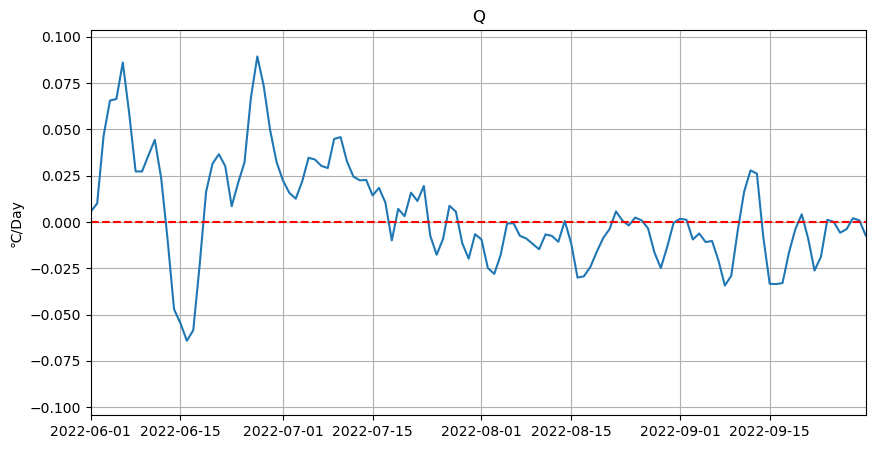

In [15]:
plt.figure(figsize=(10,5))
plt.plot(times,np.nanmean(np.nanmean(Q*3600*24,axis=-1),axis=-1))
plt.xlim(times[(times.year==2022)&(times.month==6)&(times.day==1)],times[(times.year==2022)&(times.month==9)&(times.day==30)])
plt.axhline(y=0, color='r', linestyle='--')
#plt.ylim(-1.5,1.5)
plt.ylabel('℃/Day')
plt.grid()
plt.title('Q')

## Mixed Layer Temperature Tendency

$$
Mixed Layer Temperature Tendency=\frac{\mathrm{d}\mathrm{T_{m}}}{\mathrm{d}\mathrm{t}}
$$

In [16]:
def clim_core(dat):
    global t,YEARL,YEARL
    #print(t.shape)
    if np.sum(np.isnan(dat))>=100:
        a=np.zeros(shape=t.shape)
        a[:]=np.nan
        return a
    else:
        try:
            return Clim(t,dat,climatologyPeriod=[YEARL,YEARR],smoothPercentile=True)
        except:
            a=np.zeros(shape=t.shape)
            a[:]=np.nan
            return a
def list_map_clim(dat):
    pool = ThreadPoolExecutor(max_workers=3)
    ans=np.array(list(map(clim_core,dat)))
    del pool
    return ans
def Clim_allinone(dat):
    a=np.swapaxes(dat,0,1)
    a=np.swapaxes(a,1,2)
    #print(a.shape)
    pool = ProcessPoolExecutor(max_workers=61)
    ans=np.array(list(pool.map(list_map_clim,a)))
    ans=np.swapaxes(ans,1,2)
    ans=np.swapaxes(ans,0,1)
    del pool
    return ans
def Ano_allinone(dat):    
    return dat-Clim_allinone(dat)
mlt_grid_level=np.broadcast_to(level[np.newaxis,:-1,np.newaxis,np.newaxis],Bran_temp.shape)
selector = mlt_grid_level >= np.broadcast_to(Bran_mld[:, np.newaxis, ...], Bran_temp.shape)
potential_t_below_mld = np.ma.masked_array(Bran_temp, mask=selector)
mlt=np.array(np.nanmean(potential_t_below_mld,axis=1))
t= np.arange(date(1993,1,1).toordinal(),date(2022,12,31).toordinal())# For ClimCal
mltt=Ano_allinone(detrend_allinone(mlt[:-1,:,:]-mlt[1:,:,:]))

/tmp/ipykernel_253781/3751862532.py:35: RuntimeWarning: Mean of empty slice
  mlt=np.array(np.nanmean(potential_t_below_mld,axis=1))


Text(0.5, 1.0, 'mltt')

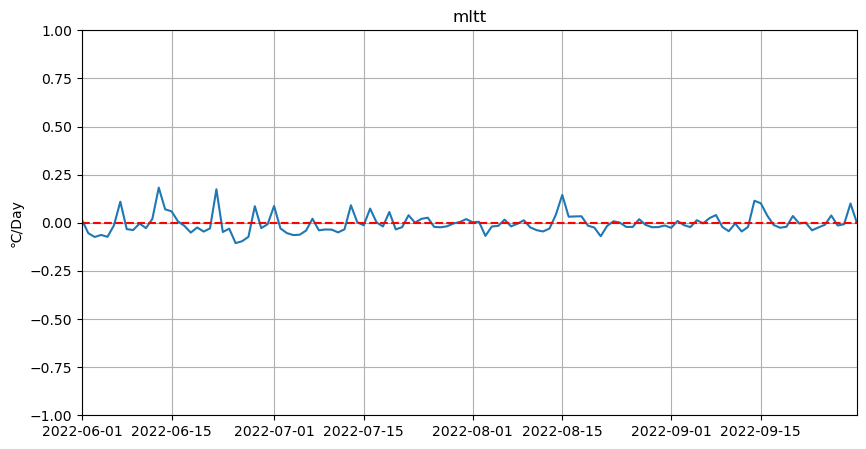

In [17]:
plt.figure(figsize=(10,5))
plt.plot(times[:-1],np.nanmean(np.nanmean(mltt,axis=-1),axis=-1))
plt.xlim(times[(times.year==2022)&(times.month==6)&(times.day==1)],times[(times.year==2022)&(times.month==9)&(times.day==30)])
plt.axhline(y=0, color='r', linestyle='--')
plt.ylim(-1,1)
plt.ylabel('℃/Day')
plt.grid()
plt.title('mltt')

(-0.3, 0.3)

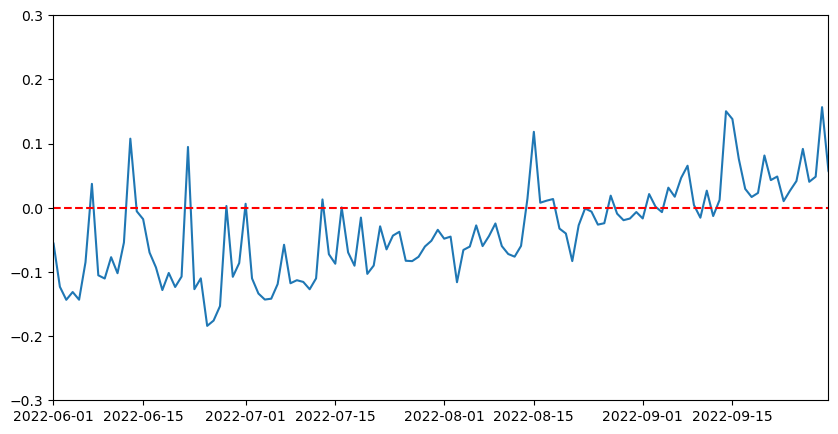

In [34]:
plt.figure(figsize=(10,5))
plt.plot(times[:-1],np.nanmean(np.nanmean(mlt[:-1,:,:]-mlt[1:,:,:],axis=-1),axis=-1))
plt.xlim(times[(times.year==2022)&(times.month==6)&(times.day==1)],times[(times.year==2022)&(times.month==9)&(times.day==30)])
plt.axhline(y=0, color='r', linestyle='--')
plt.ylim(-0.3,0.3)
#plt.ylim(-1.5,1.5)
# plt.ylabel('℃/Day')
# plt.grid()
# plt.title('Q')

## HADV 水平平流项

$$
HADV=-\overrightarrow{U_{m}}\bigtriangledown T_{m}=-(u_{m}\frac{\mathrm{d}T_{m}}{\mathrm{d}x}+v_{m}\frac{\mathrm{d}T_{m}}{\mathrm{d}y})
$$
- $ \overrightarrow{U_{m}} $为0~h平均水平速度
- $T_{m}$为0~-h深度的平均位温
- $u_{m}$为水平经向速度
- $v_{m}$为水平纬向速度
- 注：纬度长度不固定，需要进行修正，修正公式:$111(Δ lon)\cdot cos(lat)$

In [19]:
u_grid_level=np.broadcast_to(level[np.newaxis,:-1,np.newaxis,np.newaxis],Bran_u.shape)
selector = u_grid_level >= np.broadcast_to(Bran_mld[:, np.newaxis, ...], Bran_u.shape)
v_below_mld = np.ma.masked_array(Bran_u, mask=selector)
us=np.array(np.nanmean(v_below_mld,axis=1))
v_grid_level=np.broadcast_to(level[np.newaxis,:-1,np.newaxis,np.newaxis],Bran_v.shape)
selector = v_grid_level >= np.broadcast_to(Bran_mld[:, np.newaxis, ...], Bran_v.shape)
v_below_mld = np.ma.masked_array(Bran_v, mask=selector)
vs=np.array(np.nanmean(v_below_mld,axis=1))



/tmp/ipykernel_253781/1133816210.py:4: RuntimeWarning: Mean of empty slice
  us=np.array(np.nanmean(v_below_mld,axis=1))
/tmp/ipykernel_253781/1133816210.py:8: RuntimeWarning: Mean of empty slice
  vs=np.array(np.nanmean(v_below_mld,axis=1))


In [20]:

dx=np.array([(mlt[:,i,1:]-mlt[:,i,:-1])/(111e3/4*np.cos(lat[i]/180*np.pi)) for i in range(0,lat.shape[0])])
dx=np.swapaxes(dx,0,1)
dy=(mlt[:,1:,:]-mlt[:,:-1,:])/(111e3/4)


In [21]:

t= np.arange(date(1993,1,1).toordinal(),date(2022,12,31).toordinal()+1)# For ClimCal
hadv=Ano_allinone(detrend_allinone((us[:,:-1,:-1]*dx[:,:-1,:]+vs[:,:-1,:-1]*dy[:,:,:-1])*-1))

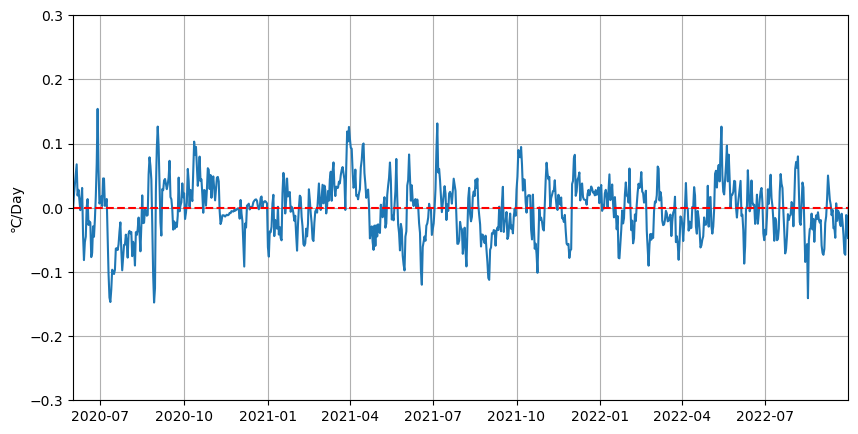

In [22]:
plt.figure(figsize=(10,5))
plt.plot(times,np.nanmean(np.nanmean(hadv[:,:-1,:-1]*24*3600,axis=-1),axis=-1))
plt.xlim(times[(times.year==2020)&(times.month==6)&(times.day==1)],times[(times.year==2022)&(times.month==9)&(times.day==30)])
plt.axhline(y=0, color='r', linestyle='--')
plt.ylim(-0.3,0.3)
plt.ylabel('℃/Day')
plt.grid()
#plt.title('hadv')

In [23]:
np.savez('20230525HeatBudget&HeatWave.npz',mltt=mltt,Q=Q*3600*24,hadv=hadv*24*3600)

In [24]:
np.savez('20230525HeatBudget&HeatWave.npz',mltt=mltt,Q=Q*3600*24,hadv=hadv*24*3600)

In [25]:
np.savez('20230525HeatBudget&HeatWave_2020_2022.npz',
         mltt=mltt[(times[1:].year>=2020)],
         Q=(Q*3600*24)[(times.year>=2020)],
         hadv=(hadv*24*3600)[(times.year>=2020)],
         lon=lon,
         lat=lat)

In [26]:
mltt[(times[1:].year>=2020)].shape

(1096, 21, 51)

/tmp/ipykernel_253781/2084710863.py:1: RuntimeWarning: Mean of empty slice
  test=np.nanmean(np.nanmean(np.nanmean(Bran_temp,axis=-1),axis=-1),axis=-1)


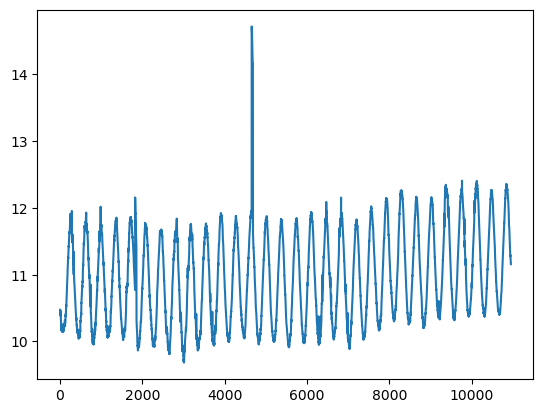

In [32]:
test=np.nanmean(np.nanmean(np.nanmean(Bran_temp,axis=-1),axis=-1),axis=-1)
ind=test>=70
plt.plot(test)
# plt.ylim(0,40)
# plt.xlim(0,1000)

In [28]:
ind=test>=70

In [29]:
times_i=times[ind]
print(np.array(times_i))

[]


In [30]:
np.mean(Bran_temp[ind,:,:,:],axis=1).shape

(0, 21, 51)

In [31]:
test=np.mean(Bran_temp[ind,:,:,:],axis=1)[0,:,:]
#test[test<=-1000]=np.nan
plt.contourf(test)
plt.colorbar()

IndexError: index 0 is out of bounds for axis 0 with size 0